```
Dataset
   ↓
EDA (explore dataset)
   ↓
Data preprocessing
   ↓
Dataset + DataLoader
   ↓
Model architecture
   ↓
Training loop
   ↓
Evaluation metrics
   ↓
Visualization prediction
   ↓
Model improvement
```

In [1]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.8 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

In [3]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Dataset

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import pandas as pd

# Dataset path
BASE_PATH = "/kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1"
TRAIN_PATH = os.path.join(BASE_PATH, "Train", "Labeled")
categories = ["Flooded", "Non-Flooded"]

print("Dataset path:", TRAIN_PATH)

Dataset path: /kaggle/input/datasets/aletbm/aerial-imagery-dataset-floodnet-challenge/FloodNet Challenge - Track 1/Train/Labeled


# EDA (explore dataset)

In [5]:
for root, dirs, files in os.walk(TRAIN_PATH):
    level = root.replace(TRAIN_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for f in files[:3]:
        print(f'{subindent}{f}')

data_count = {}

for category in categories:
    
    img_dir = os.path.join(TRAIN_PATH, category, "image")
    mask_dir = os.path.join(TRAIN_PATH, category, "mask")
    
    img_count = len(os.listdir(img_dir))
    mask_count = len(os.listdir(mask_dir))
    
    data_count[category] = {
        "images": img_count,
        "masks": mask_count
    }

print("Dataset Distribution")
print(pd.DataFrame(data_count).T)

# all_classes = set()

# for category in categories:

#     mask_dir = os.path.join(TRAIN_PATH, category, "mask")

#     for file in os.listdir(mask_dir):

#         path = os.path.join(mask_dir, file)

#         mask = cv2.imread(path, 0)

#         unique = np.unique(mask)

#         all_classes.update(unique)

# print("All classes in dataset:", sorted(all_classes))
# print("Total classes:", len(all_classes))

Labeled/
  Flooded/
    mask/
      7325_lab.png
      7524_lab.png
      6614_lab.png
    image/
      8379.jpg
      7405.jpg
      10166.jpg
  Non-Flooded/
    mask/
      7884_lab.png
      8350_lab.png
      6727_lab.png
    image/
      8075.jpg
      6459.jpg
      7918.jpg
Dataset Distribution
             images  masks
Flooded          51     51
Non-Flooded     347    347


In [6]:
# pixel_counter = Counter()

# for category in categories:

#     mask_dir = os.path.join(TRAIN_PATH, category, "mask")

#     for file in os.listdir(mask_dir)[:50]:  # sample 50 masks for speed

#         path = os.path.join(mask_dir, file)
#         mask = cv2.imread(path, 0)

#         values, counts = np.unique(mask, return_counts=True)

#         for v,c in zip(values, counts):
#             pixel_counter[v] += c

# pixel_df = pd.DataFrame({
#     "class": list(pixel_counter.keys()),
#     "pixels": list(pixel_counter.values())
# })

# plt.figure(figsize=(8,5))

# sns.barplot(data=pixel_df, x="class", y="pixels", palette="viridis")

# plt.title("Pixel Distribution per Class")
# plt.xlabel("Class ID")
# plt.ylabel("Number of Pixels")

# plt.show()

In [7]:
# widths = []
# heights = []

# for category in categories:

#     img_dir = os.path.join(TRAIN_PATH, category, "image")

#     for file in os.listdir(img_dir):

#         path = os.path.join(img_dir, file)

#         img = Image.open(path)

#         w, h = img.size

#         widths.append(w)
#         heights.append(h)

In [8]:
# plt.figure(figsize=(12,5))

# plt.subplot(1,2,1)
# sns.histplot(widths, bins=20, kde=True)
# plt.title("Image Width Distribution")

# plt.subplot(1,2,2)
# sns.histplot(heights, bins=20, kde=True)
# plt.title("Image Height Distribution")

# plt.show()

In [9]:
# plt.figure(figsize=(15,8))

# idx = 1

# for category in categories:

#     img_dir = os.path.join(TRAIN_PATH, category, "image")

#     images = os.listdir(img_dir)[:3]

#     for file in images:

#         img = cv2.imread(os.path.join(img_dir, file))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         plt.subplot(2,3,idx)
#         plt.imshow(img)
#         plt.title(category)
#         plt.axis("off")

#         idx += 1

# plt.tight_layout()
# plt.show()

In [10]:
# plt.figure(figsize=(15,10))

# idx = 1

# for category in categories:

#     img_dir = os.path.join(TRAIN_PATH, category, "image")
#     mask_dir = os.path.join(TRAIN_PATH, category, "mask")

#     images = os.listdir(img_dir)[:2]

#     for file in images:

#         img = cv2.imread(os.path.join(img_dir, file))
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         mask_file = file.replace(".jpg", "_lab.png")
#         mask = cv2.imread(os.path.join(mask_dir, mask_file), 0)

#         plt.subplot(2,4,idx)
#         plt.imshow(img)
#         plt.title("Image")
#         plt.axis("off")

#         plt.subplot(2,4,idx+1)
#         plt.imshow(mask, cmap="jet")
#         plt.title("Mask")
#         plt.axis("off")

#         idx += 2

# plt.tight_layout()
# plt.show()

In [11]:
classes = {
    0:"Background",
    1:"Building",
    2:"Road",
    3:"Water",
    4:"Tree",
    5:"Vehicle",
    6:"Pool",
    7:"Grass",
    8:"Flooded Building",
    9:"Flooded Road"
}

print(classes)

{0: 'Background', 1: 'Building', 2: 'Road', 3: 'Water', 4: 'Tree', 5: 'Vehicle', 6: 'Pool', 7: 'Grass', 8: 'Flooded Building', 9: 'Flooded Road'}


# Data preprocessing

In [12]:
image_paths = []
mask_paths = []

for category in categories:

    img_dir = os.path.join(TRAIN_PATH, category, "image")
    mask_dir = os.path.join(TRAIN_PATH, category, "mask")

    for file in os.listdir(img_dir):

        img_path = os.path.join(img_dir, file)

        mask_file = file.replace(".jpg", "_lab.png")
        mask_path = os.path.join(mask_dir, mask_file)

        image_paths.append(img_path)
        mask_paths.append(mask_path)

print("Total images:", len(image_paths))

Total images: 398


In [13]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths,
    mask_paths,
    test_size=0.2,
    random_state=42
)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))

Train: 318
Validation: 80


In [14]:
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(-0.1, 0.1),
        rotate=(-30, 30),
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    # A.GaussNoise(p=0.2),
    # A.CoarseDropout(
    #     num_holes_range=(1, 8),
    #     hole_height_range=(16, 64),
    #     hole_width_range=(16, 64),
    #     p=0.5
    # ),
    # A.HueSaturationValue(p=0.3),
    A.RandomGamma(p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
], is_check_shapes=False)

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], is_check_shapes=False)

In [15]:
class FloodDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # grayscale → shape (H,W)
        
        if image is None or mask is None:
            raise FileNotFoundError(f"Không đọc được: {img_path} hoặc {mask_path}")
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]
        
        mask = mask.long()  # cho CrossEntropyLoss
        
        return image, mask

In [16]:
# Tạo dataset & loader như cũ
train_dataset = FloodDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = FloodDataset(val_imgs,   val_masks,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

In [17]:
images, masks = next(iter(train_loader))
print("Images shape:", images.shape)   # mong đợi: [4, 3, 512, 512]
print("Masks shape: ", masks.shape)    # mong đợi: [4, 512, 512]
print("Masks dtype: ", masks.dtype)     # mong đợi: torch.int64

Images shape: torch.Size([4, 3, 512, 512])
Masks shape:  torch.Size([4, 512, 512])
Masks dtype:  torch.int64


# Model architecture

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ========================= ATTENTION GATE & ASPP (giữ nguyên) =========================
class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.w_g = nn.Conv2d(g_channels, inter_channels, kernel_size=1)
        self.w_x = nn.Conv2d(x_channels, inter_channels, kernel_size=1)
        self.psi = nn.Conv2d(inter_channels, 1, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, g, x):
        g1 = self.w_g(g)
        x1 = self.w_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        psi = self.sigmoid(psi)
        return x * psi

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=512, rates=[1, 6, 12, 18]):
        super().__init__()
        self.aspp1 = nn.Conv2d(in_channels, out_channels, 1)
        self.aspp2 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[1], dilation=rates[1])
        self.aspp3 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[2], dilation=rates[2])
        self.aspp4 = nn.Conv2d(in_channels, out_channels, 3, padding=rates[3], dilation=rates[3])
        
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1),
            nn.ReLU(inplace=True)
        )
        self.out_conv = nn.Conv2d(out_channels * 5, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        f1, f2, f3, f4 = self.aspp1(x), self.aspp2(x), self.aspp3(x), self.aspp4(x)
        f5 = self.global_pool(x)
        f5 = F.interpolate(f5, size=x.shape[2:], mode='bilinear', align_corners=False)
        out = torch.cat([f1, f2, f3, f4, f5], dim=1)
        out = self.out_conv(out)
        out = self.bn(out)
        return self.relu(out)

# ========================= TransformerBlock =========================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=8, mlp_ratio=4.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

# ========================= DecoderBlock =========================
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        # self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Thay ConvTranspose bằng Upsample + Conv
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.att_gate = AttentionGate(out_channels, skip_channels, out_channels//2) if skip_channels > 0 else None
        
        total_in = out_channels + skip_channels if skip_channels > 0 else out_channels
        self.conv = nn.Sequential(
            nn.Conv2d(total_in, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    
    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None and self.att_gate is not None:
            skip = F.interpolate(skip, size=x.shape[2:], mode='bilinear', align_corners=False)
            skip = self.att_gate(x, skip)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

# ========================= HybridEncoder (ResNet50 + depth=12) =========================
class HybridEncoder(nn.Module):
    def __init__(self, img_size=512, patch_size=4, dim=512, depth=12, backbone_name='convnext_tiny'):
        """
        Hybrid Encoder với CNN backbone + Patch Embedding + Transformer
        - patch_size: kích thước patch (nên dùng 4 hoặc 2 để có đủ tokens)
        - backbone_name: 'resnet50', 'convnext_tiny', 'convnext_small',...
        """
        super().__init__()
        
        self.backbone_name = backbone_name
        self.backbone = timm.create_model(backbone_name, pretrained=True, features_only=True)
        
        # Xác định channel cho patch_embed và skip connections
        if 'resnet50' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [64, 256, 512, 1024]   # level 0,1,2,3
        elif 'convnext_tiny' in backbone_name or 'convnext_small' in backbone_name:
            self.patch_in_ch = 768
            self.skip_channels = [96, 192, 384, 768]
        elif 'convnext_base' in backbone_name:
            self.patch_in_ch = 1024
            self.skip_channels = [128, 256, 512, 1024]
        else:
            raise ValueError(f"Unsupported backbone: {backbone_name}. Please add config.")
        
        # Patch embedding
        self.patch_embed = nn.Conv2d(self.patch_in_ch, dim, kernel_size=patch_size, stride=patch_size)
        
        # Positional embedding: tạo max size trước (an toàn, tránh dynamic trong forward)
        # Max giả định: patch_size=2 trên 16x16 → 64 tokens
        max_patches = (32 // 2) ** 2  # 256 cho an toàn
        self.pos_embedding = nn.Parameter(torch.randn(1, max_patches, dim))
        
        # Transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock(dim) for _ in range(depth)])

    def forward(self, x):
        features = self.backbone(x)  # list of feature maps
        
        # Lấy skip connections (level 0→3: high-res → low-res)
        x1, x2, x3, x4 = features[0], features[1], features[2], features[3]
        
        # Patch embedding từ level 3 (x4)
        patch_feat = self.patch_embed(x4)
        B, C, h, w = patch_feat.shape
        
        # Số patch thực tế
        num_patches = h * w
        
        # Slice pos_embedding theo số patch thực tế
        pos = self.pos_embedding[:, :num_patches, :]
        
        # Flatten & add pos
        tokens = patch_feat.flatten(2).transpose(1, 2)  # B, num_patches, dim
        tokens = tokens + pos
        
        # Transformer blocks
        for blk in self.blocks:
            tokens = blk(tokens)
        
        return tokens, x1, x2, x3, x4, h, w

# ========================= ViT-UNet (đã fix Deep Supervision) =========================
class ViT_UNet(nn.Module):
    def __init__(self, num_classes=10, dim=512, backbone_name='convnext_tiny'):
        super().__init__()
        self.encoder = HybridEncoder(img_size=512, patch_size=4, dim=dim, depth=12, backbone_name=backbone_name)
        
        # Lấy skip channels từ encoder (đã fix)
        skip_ch = self.encoder.skip_channels
        
        self.aspp = ASPP(dim, dim)
        
        self.dec1 = DecoderBlock(dim,   skip_ch[3], 256)   # skip x4 (lowest res)
        self.dec2 = DecoderBlock(256,   skip_ch[2], 128)   # skip x3
        self.dec3 = DecoderBlock(128,   skip_ch[1],  64)   # skip x2
        self.dec4 = DecoderBlock(64,    skip_ch[0],  32)   # skip x1 (highest res)
        self.dec5 = DecoderBlock(32,           0,   32)
        
        self.head = nn.Conv2d(32, num_classes, 1)
        
        self.aux_head2 = nn.Conv2d(128, num_classes, 1)
        self.aux_head3 = nn.Conv2d(64,  num_classes, 1)

    def forward(self, x):
        tokens, x1, x2, x3, x4, H, W = self.encoder(x)
        B, N, C = tokens.shape
        feat = tokens.transpose(1, 2).reshape(B, C, H, W)
        
        feat = self.aspp(feat)
        
        feat1 = self.dec1(feat, x4)
        feat2 = self.dec2(feat1, x3)
        feat3 = self.dec3(feat2, x2)
        feat4 = self.dec4(feat3, x1)
        feat5 = self.dec5(feat4, None)
        
        main_out = self.head(feat5)
        main_out = F.interpolate(main_out, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux2 = self.aux_head2(feat2)
        aux2 = F.interpolate(aux2, size=(512, 512), mode='bilinear', align_corners=False)
        
        aux3 = self.aux_head3(feat3)
        aux3 = F.interpolate(aux3, size=(512, 512), mode='bilinear', align_corners=False)
        
        return main_out, aux2, aux3

In [19]:
if __name__ == "__main__":
    # Dùng ConvNeXt-Tiny
    model = ViT_UNet(num_classes=10, dim=512, backbone_name='convnext_tiny')
    x = torch.randn(2, 3, 512, 512)
    main, aux2, aux3 = model(x)
    print("Main output shape :", main.shape)
    print("Aux2 shape       :", aux2.shape)
    print("Aux3 shape       :", aux3.shape)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Main output shape : torch.Size([2, 10, 512, 512])
Aux2 shape       : torch.Size([2, 10, 512, 512])
Aux3 shape       : torch.Size([2, 10, 512, 512])
Trainable parameters: 86,680,082


# Training

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# =========================
# Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# Model
# =========================
model = ViT_UNet(num_classes=10).to(device)

# =========================
# Count Parameters
# =========================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Params:", count_parameters(model))

Device: cuda


Total Params: 86680082


In [21]:
def lovasz_grad(gt_sorted):
    """
    Computes gradient of the Lovász-Softmax loss w.r.t sorted errors
    See Alg. 1 in paper
    """
    p = len(gt_sorted)
    gts = gt_sorted.sum().float()
    intersection = gts - gt_sorted.float().cumsum(0)
    union = gts + (1 - gt_sorted).float().cumsum(0)
    jaccard = 1. - intersection / union
    if p > 1:  # cover 1-pixel case
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    return jaccard

def lovasz_softmax_flat(probas, labels, classes='present'):
    """
    Multi-class Lovász-Softmax loss
    probas: [B*H*W, C]
    labels: [B*H*W]
    classes: 'all' for all, 'present' for classes present in labels
    """
    if probas.numel() == 0:
        # only void pixels, the gradients are 0
        return probas * 0.
    C = probas.size(1)
    losses = []
    class_to_sum = list(range(C)) if classes in ['all', 'present'] else classes
    for c in class_to_sum:
        fg = (labels == c).float()  # foreground for class c
        if (classes is 'present' and fg.sum() == 0):
            continue
        if C == 1:
            if len(classes) > 1:
                raise ValueError('Sigmoid output possible only with 1 class')
            class_pred = probas[:, 0]
        else:
            class_pred = probas[:, c]
        errors = (fg - class_pred).abs()
        errors_sorted, perm = torch.sort(errors, 0, descending=True)
        perm = perm.data
        fg_sorted = fg[perm]
        losses.append(torch.dot(errors_sorted, lovasz_grad(fg_sorted)))
    return mean(losses)

def mean(l, ignore_nan=False, empty=0):
    """
    nanmean compatible with generators.
    """
    l = iter(l)
    if ignore_nan:
        l = ifilterfalse(isnan, l)
    try:
        n = 1
        acc = next(l)
    except StopIteration:
        if empty == 'raise':
            raise ValueError('Empty mean')
        return empty
    for n, v in enumerate(l, 2):
        acc += v
    if n == 0:
        return acc
    return acc / n

def isnan(x):
    return x != x

def ifilterfalse(predicate, iterable):
    for x in iterable:
        if not predicate(x):
            yield x

<>:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipykernel_24/3263051089.py:30: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if (classes is 'present' and fg.sum() == 0):


In [22]:
# ========================= FOCAL LOSS =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, ignore_index=0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index

    def forward(self, pred, target):
        ce_loss = F.cross_entropy(pred, target, ignore_index=self.ignore_index, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# ========================= DICE LOSS (giữ nguyên của bạn) =========================
class DiceLoss(nn.Module):
    def __init__(self, num_classes=10, ignore_index=0):
        super().__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def forward(self, pred, target, smooth=1e-6):
        pred = torch.softmax(pred, dim=1)
        target_onehot = nn.functional.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        intersection = (pred * target_onehot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
        dice = (2 * intersection + smooth) / (union + smooth + 1e-8)
        dice = dice[:, 1:]  # ignore background
        return 1 - dice.mean()

class AdvancedLoss(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes=num_classes)
        self.focal = FocalLoss(alpha=0.75, gamma=3.0)

    def forward(self, main_out, aux2, aux3, target):
        # Main loss
        main_ce   = self.ce(main_out, target)
        main_dice = self.dice(main_out, target)
        main_focal = self.focal(main_out, target)
        
        # Lovász-Softmax (bỏ background bằng cách dùng classes='present' hoặc tự filter)
        probas = F.softmax(main_out, dim=1)  # [B, C, H, W]
        probas_flat = probas.permute(0, 2, 3, 1).reshape(-1, probas.size(1))  # [B*H*W, C]
        labels_flat = target.reshape(-1)  # [B*H*W]
        
        main_lovasz = lovasz_softmax_flat(probas_flat, labels_flat, classes='present')

        # loss_main = 0.3 * main_ce + 0.3 * main_dice + 0.2 * main_focal + 0.2 * main_lovasz
        loss_main = 0.5 * main_dice + 0.5 * main_lovasz

        # Aux losses (giữ đơn giản)
        aux2_loss = 0.1 * (self.ce(aux2, target) + self.dice(aux2, target))
        aux3_loss = 0.05 * (self.ce(aux3, target) + self.dice(aux3, target))

        return loss_main + aux2_loss + aux3_loss

In [23]:
class_weights = torch.tensor([
    0.1,  # background
    1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5, 1.5
], device=device)
ce_loss = nn.CrossEntropyLoss(weight=class_weights)

# ce_loss = nn.CrossEntropyLoss()
dice_loss = DiceLoss(num_classes=10)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)  # ↓ lr + AdamW

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

# Mixed precision
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_24/1480747474.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [24]:
def dice_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    dice = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()

        intersection = (pred_cls * target_cls).sum()

        dice_cls = (2 * intersection + smooth) / (
            pred_cls.sum() + target_cls.sum() + smooth
        )

        dice += dice_cls

    return dice / num_classes


def iou_score(pred, target, num_classes=10, smooth=1e-6):

    pred = torch.argmax(pred, dim=1)

    iou = 0

    for cls in range(num_classes):

        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).float().sum()
        union = (pred_cls | target_cls).float().sum()

        iou_cls = (intersection + smooth) / (union + smooth)

        iou += iou_cls

    return iou / num_classes


def pixel_accuracy(pred, target):

    pred = torch.argmax(pred, dim=1)

    correct = (pred == target).float().sum()
    total = torch.numel(target)

    return correct / total

In [25]:
# =========================
# Early Stopping Class (bạn cung cấp)
# =========================
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss  # Vì loss càng nhỏ càng tốt → score càng lớn càng tốt

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [26]:
early_stopping = EarlyStopping(
    patience=30,              # chờ 10 epoch không cải thiện val loss
    verbose=True,
    delta=0.0001,
    path='best_model_loss.pth'  # lưu model tốt nhất theo val loss
)

In [27]:
criterion = AdvancedLoss(num_classes=10)

def train_one_epoch(model, loader):
    model.train()
    total_loss = total_dice = total_iou = total_acc = 0.0
    n = 0
    loop = tqdm(loader, desc="Training")
    
    for images, masks in loop:
        images = images.to(device)
        masks  = masks.long().to(device)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda'):
            outputs, aux2, aux3 = model(images)
            loss = criterion(outputs, aux2, aux3, masks)
        
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)  # ↓ clip chặt hơn
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            dice = dice_score(outputs, masks)
            iou  = iou_score(outputs, masks)
            acc  = pixel_accuracy(outputs, masks)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_dice += dice.item() * bs
        total_iou  += iou.item()  * bs
        total_acc  += acc.item()  * bs
        n += bs

        loop.set_postfix(loss=loss.item(), dice=dice.item(), iou=iou.item(), acc=acc.item())
    
    avg_loss = total_loss / n
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.6f}")
    return avg_loss, total_dice/n, total_iou/n, total_acc/n


# ========================= Cách 2: TTA (Test Time Augmentation) =========================
def tta_predict(model, images):
    """TTA đơn giản: gốc + flip ngang + flip dọc + flip cả 2"""
    preds = []
    with torch.no_grad():
        # 1. Original
        main, _, _ = model(images)
        preds.append(main)
        
        # 2. Flip ngang
        flip_h = torch.flip(images, dims=[3])
        main_h, _, _ = model(flip_h)
        preds.append(torch.flip(main_h, dims=[3]))
        
        # 3. Flip dọc
        flip_v = torch.flip(images, dims=[2])
        main_v, _, _ = model(flip_v)
        preds.append(torch.flip(main_v, dims=[2]))
        
        # 4. Flip cả ngang và dọc
        flip_hv = torch.flip(images, dims=[2, 3])
        main_hv, _, _ = model(flip_hv)
        preds.append(torch.flip(main_hv, dims=[2, 3]))
    
    # Trung bình xác suất
    return torch.mean(torch.stack(preds), dim=0)

def val_loss_fn(pred, target):
    ce = F.cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return 0.5 * ce + 0.5 * dice

def validate(model, loader):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_acc = 0.0
    n = 0

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validation"):
            images = images.to(device)
            masks = masks.long().to(device)
            
            # Sử dụng TTA
            outputs = tta_predict(model, images)
            
            loss = val_loss_fn(outputs, masks)
            
            dice = dice_score(outputs, masks)
            iou = iou_score(outputs, masks)
            acc = pixel_accuracy(outputs, masks)
            
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_dice += dice.item() * batch_size
            total_iou += iou.item() * batch_size
            total_acc += acc.item() * batch_size
            n += batch_size

    return total_loss / n, total_dice / n, total_iou / n, total_acc / n

In [28]:
num_epochs = 150

best_dice = 0.0
best_iou = 0.0
best_acc = 0.0

train_loss_history, val_loss_history = [], []
train_dice_history, val_dice_history = [], []
train_iou_history, val_iou_history = [], []
train_acc_history, val_acc_history = [], []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    train_loss, train_dice, train_iou, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_dice, val_iou, val_acc = validate(model, val_loader)
    
    scheduler.step(val_loss)
    
    # Lưu lịch sử
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_dice_history.append(train_dice)
    val_dice_history.append(val_dice)
    train_iou_history.append(train_iou)
    val_iou_history.append(val_iou)
    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    
    print(f"Train → Acc: {train_acc:.4f} | Loss: {train_loss:.4f} | Dice: {train_dice:.4f} | IoU: {train_iou:.4f}")
    print(f"Val   → Acc: {val_acc:.4f} | Loss: {val_loss:.4f} | Dice: {val_dice:.4f} | IoU: {val_iou:.4f}")
    
    # Lưu model tốt nhất theo Dice
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_vit_unet_dice.pth")
        print(f"→ Best model saved! (val Dice: {val_dice:.4f})")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_model_iou.pth")
        print(f"→ Best model saved! (val IoU: {val_iou:.4f})")

    if val_acc > best_acc:
        best_acc = val_acc
    
    # Early stopping theo validation loss
    early_stopping(val_loss, model)
    
    if early_stopping.early_stop:
        print("\nEarly stopping triggered! Training dừng sớm.")
        break

print("\nTraining hoàn tất!")
print(f"Best validation Acc: {best_acc:.4f}")
print(f"Best validation Dice: {best_dice:.4f}")
print(f"Best validation IoU: {best_iou:.4f}")
print(f"Best validation loss (theo EarlyStopping): {early_stopping.val_loss_min:.6f}")


Epoch 1/150


Training: 100%|██████████| 80/80 [01:00<00:00,  1.31it/s, acc=0.266, dice=0.141, iou=0.104, loss=1.35]


Current LR: 0.000030


Validation: 100%|██████████| 20/20 [00:13<00:00,  1.49it/s]


Train → Acc: 0.1658 | Loss: 1.3922 | Dice: 0.0835 | IoU: 0.0521
Val   → Acc: 0.2568 | Loss: 1.5918 | Dice: 0.0673 | IoU: 0.0451
→ Best model saved! (val Dice: 0.0673)
→ Best model saved! (val IoU: 0.0451)
Validation loss decreased (inf --> 1.591848).  Saving model ...

Epoch 2/150


...

Train → Acc: 0.9382 | Loss: 0.5880 | Dice: 0.8137 | IoU: 0.7591
Val   → Acc: 0.8745 | Loss: 0.6794 | Dice: 0.7433 | IoU: 0.6724
EarlyStopping counter: 29 out of 30

Epoch 130/150


Training: 100%|██████████| 80/80 [00:37<00:00,  2.14it/s, acc=0.957, dice=0.719, iou=0.665, loss=0.501]


Current LR: 0.000030


Validation: 100%|██████████| 20/20 [00:10<00:00,  1.93it/s]


Train → Acc: 0.9346 | Loss: 0.5909 | Dice: 0.8143 | IoU: 0.7583
Val   → Acc: 0.8742 | Loss: 0.6698 | Dice: 0.7522 | IoU: 0.6825
→ Best model saved! (val Dice: 0.7522)
→ Best model saved! (val IoU: 0.6825)
EarlyStopping counter: 30 out of 30

Early stopping triggered! Training dừng sớm.

Training hoàn tất!
Best validation Acc: 0.8749
Best validation Dice: 0.7522
Best validation IoU: 0.6825
Best validation loss (theo EarlyStopping): 0.654836


# Visualize

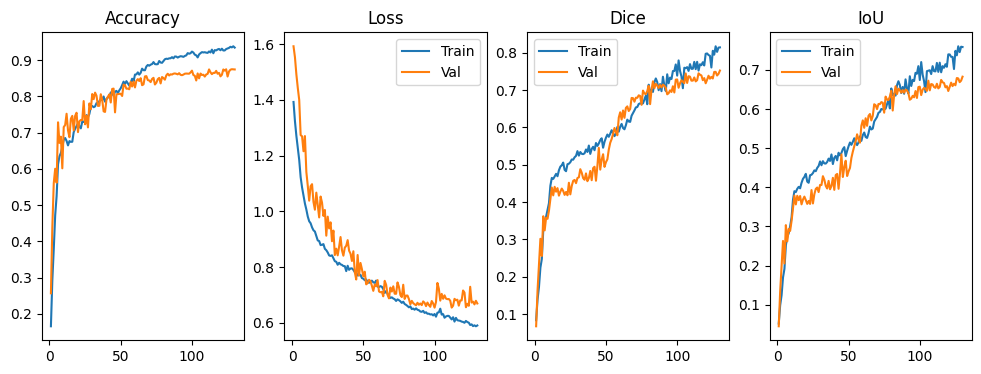

Training Finished


In [29]:
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.plot(epochs, train_acc_history, label="Train")
plt.plot(epochs, val_acc_history, label="Val")
plt.title("Accuracy")

plt.subplot(1,4,2)
plt.plot(epochs, train_loss_history, label="Train")
plt.plot(epochs, val_loss_history, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,4,3)
plt.plot(epochs, train_dice_history, label="Train")
plt.plot(epochs, val_dice_history, label="Val")
plt.title("Dice")
plt.legend()

plt.subplot(1,4,4)
plt.plot(epochs, train_iou_history, label="Train")
plt.plot(epochs, val_iou_history, label="Val")
plt.title("IoU")
plt.legend()

plt.show()

print("Training Finished")